# Referencia- és kiterjesztett implementáció konzisztencia-ellenőrzése

Ez a notebook a **„A Crouch-féle szimulációs prevalencia-becslés kiterjesztése folytonos időbeli modellezésre”** című szakdolgozat validációs anyaga.  
A dolgozat a Crouch-féle incidencia–túlélés alapú Monte Carlo szimulációs prevalenciabecslés elméleti keretére és az R csomagként telepíthető `rprev` referencia-implementációra épül. A központi feladat a referencia-eljárás több indexdátum együttes kezelésére szolgáló kiterjesztése, valamint ennek módszertani és numerikus validálása (lásd: dolgozat 3–5. fejezet).

A referencia csomag dokumentációja: https://cloud.r-project.org/web/packages/rprev/

A fentieknek megfelelően a **referencia** implementáció definíció szerint egyetlen indexdátumhoz ad prevalencia-becslést, ezért több indexdátum esetén az eredmény az rprev `prevalence()` függvényének többszörös egy-indexű függvényhívásainak sorozatából állítható elő. A **kiterjesztett implementáció** ezzel szemben több indexdátum együttes kezelésére készült, és a teljes indexrácsra konzisztens becslést ad egy közös futási keretben (lásd: 4. fejezet – referencia implementáció és a kiterjesztés tárgya; 5. fejezet – matematikai modell és csomagszintű illesztés).

## Validációs cél

A notebook célja annak vizsgálata, hogy a referencia implementációból indexdátumonként összeállított kimenet-sorozat és a natív többindexű kiterjesztett futtatás kimenete azonos bemenetek (adat, modellek, paraméterek, indexdátumok) mellett összevethető-e, továbbá hogy a megfigyelt eltérések a kiterjesztés definiált módszertani és algoritmikus sajátosságai mellett értelmezhetők-e.

## Egyezési kritériumok és eltérésértelmezés

A két implementáció futási szerkezete eltér, ezért a véletlenszám-generátor hívásainak száma és ütemezése sem azonos (lásd dolgozat 5. fejezet). A referencia-megoldás indexdátumonként külön futtatással állít elő prevalencia-becslést, így a bináris státuszok véletlen komponense is indexdátumonként, elkülönülő Bernoulli-sorsolásokon keresztül képződik. Ezzel szemben a kiterjesztett megoldásban a státuszképzés véletlen komponense esetszinten egyetlen `xi ~ Unif(0,1)` küszöbhöz kötött, és ezt hasonlítjuk össze az indexrács pontjaihoz tartozó túlélési valószínűségekkel. A két státuszképzési szervezés különbsége miatt azonos induló véletlenmag mellett sem várható bitazonos kimenet. 

Az összevetést a kimeneti összefoglalók (pontbecslés, intervallumhatárok) szintjén végezzük. A referencia és a kiterjesztett implementáció kimenetét akkor tekintjük konzisztensnek, ha a relatív eltérések az indexrácson kontrolláltak. A pontbecslésre a

$$
\delta_{\widehat{P}}(t_k)
=
\frac{\widehat{P}_{\mathrm{ext}}(t_k)-\widehat{P}_{\mathrm{ref}}(t_k)}{\widehat{P}_{\mathrm{ref}}(t_k)}
$$

relatív eltérést, míg az intervallumhatárokra (minden $\alpha\in\{0.025,\,0.975\}$ esetén) a

$$
\delta_{q,\alpha}(t_k)
=
\frac{q_{\alpha,\mathrm{ext}}(t_k)-q_{\alpha,\mathrm{ref}}(t_k)}{q_{\alpha,\mathrm{ref}}(t_k)}
$$

relatív eltérést képezzük. Az egyezést a rácson vett eltérések nagyságrendje alapján értékeljük. A kiértékelést az `rprev` csomag által tartalmazott `prevsim` szintetikus regiszter-adathalmazon végezzük, és a paraméterezést — különösen az indexdátumokat és a becslési horizontokat — úgy választjuk meg, hogy a becsléshez a regiszter kezdete előtt diagnosztizált esetek hozzájárulása pontosan 10 évnyi szimulált incidens populációt fedjen le. A teljes diagnosztikai vizsgálatot ennél szélesebb indexdátum- és horizontkészleten is lefuttatjuk, ugyanakkor a formális egyezési kritériumok értékelését az itt rögzített konfiguráció alapján adjuk meg. Rögzített $N_{\mathrm{sim}}=N_{\mathrm{boot}}=5000$ mellett az egyezést akkor tekintjük teljesültnek, ha a rácson vett pontbecslés-eltérésekre $\max_k |\delta_{\widehat{P}}(t_k)| \leq 10^{-3}$, a konfidencia-intervallumok határaira pedig $\max_k |\delta_{q,\alpha}(t_k)| \leq 5\cdot 10^{-3}$ teljesül. Ennek indoka, hogy a pontbecslés bootstrap-átlagként, az intervallumhatár pedig bootstrap-kvantilisként áll elő. A szélső kvantilisek becslése tipikusan érzékenyebb, mert a hozzájuk tartozó $q_\alpha$ pontok az eloszlás farokrészében helyezkednek el, ahol a sűrűség rendszerint kicsi, ezért ugyanakkora eloszlásfüggvény-perturbáció nagyobb kvantiliseltérést okoz. Ennek megfelelően a konfidencia-intervallumok határaira megengedőbb egyezési küszöböt alkalmazunk. Az összevetést 10 különböző véletlenmag-beállítás mellett ismételjük meg, hogy a megállapítás ne egyetlen véletlen realizációhoz kötődjön.

A konzisztencia értelmezéséhez két további diagnosztikai ellenőrzést is végzünk:

- az eltérések az indexrács mentén nem mutatnak tartós, egyirányú eltolódást;

- a szimulációs ismétlésszám növelésével ($N_{\mathrm{sim}}$,$N_{\mathrm{boot}}$) a relatív eltérések a nullához konvergálnak, vagyis az indexrácson mért $|\delta_{\widehat{P}}(t_k)|$ és $|\delta_{q,\alpha}(t_k)|$ mennyiségek rendre csökkennek.

## Notebook felépítése

1. Közös paraméterezés rögzítése.  
2. Referencia-kimenet előállítása indexdátumonkénti, egyindexű `prevalence()` hívások sorozatával.  
3. Kiterjesztett implementáció futtatása a teljes indexrácsra.  
4. Célzott összevetés a kimenetszintű mennyiségekre (pontbecslés és intervallumhatárok) az indexrácson.  
5. Konvergenciaellenőrzés: a szimulációs ismétlésszám növelésével ($N_{\mathrm{sim}}$, $N_{\mathrm{boot}}$) a referencia-kiterjesztett relatív eltérések nullához tartásának vizsgálata.

---
### 1. Közös paraméter konfiguráció
- A referencia és a kiterjesztett megoldása futtatása ugyanebből a paraméterkészletből dolgozik, így az összevetés konzisztens.

In [1]:
# Közös konfiguráció a futtatásokhoz
seeds <- c(20260301, 20260302, 20260303, 20260304, 20260305, 20260306, 20260307, 20260308, 20260309, 20260310)
seed <- seeds[1]
N_boot <- 5000L
num_years <- c(5, 10, 15, 20)

# Indexdátum-rács beállítása
K <- 3L
index_start <- as.Date("2012-01-07")
index_dates <- seq.Date(from = index_start, by = "year", length.out = K)

# Modell- és prevalenciabecslési paraméterek
inc_formula <- entrydate ~ sex
surv_formula <- survival::Surv(time, status) ~ age + sex
dist <- "weibull"
population_size <- 1e7
death_column <- "eventdate"
status_col <- "status"


### 2. Környezet előkészítése
- Betöltjük a szükséges csomagokat (`rprev`, `survival`, `lubridate`), valamint a `prevsim` példaadatot.
- A betöltött adatokból előállítjuk a futtatásokhoz használt munkatáblát (`base_df`), amelyet a későbbi összevetések során konzisztensen használunk.

In [2]:
# Szükséges csomagok betöltése
suppressPackageStartupMessages({
  library(rprev)
  library(survival)
  library(lubridate)
})

# A beépített példaadat előkészítése
data(prevsim, package = "rprev")
base_df <- as.data.frame(prevsim)

# A regiszter kezdeti dátumának meghatározása
registry_start_date <- min(base_df$entrydate, na.rm = TRUE)
registry_start_date


Warning message:
"package 'rprev' was built under R version 4.4.3"
Warning message:
"package 'lubridate' was built under R version 4.4.3"


[1] "2003-01-07"

### 3. Referencia `rprev` implementáció futtatása
- A referencia implementáció `prevalence()` függvénye egyetlen indexdátumra ad becslést. 
- Több indexdátum esetén az eredmény indexdátumonként ismételt különálló futtatásokból állítjuk elő.
- Az összevetést 10 különböző véletlenmag-beállítás mellett ismételjük meg, hogy a megállapítás ne egyetlen véletlen realizációhoz kötődjön.

In [7]:
# Referencia-kimenetek előállítása több indexdátumra
ref_abs_table_by_seed <- list()
res_ref_by_index_by_seed <- list()

# Az abszolút prevalencia kinyerése horizontonként egy futtatás kimenetéből
extract_abs <- function(res) {
  out <- sapply(num_years, function(y) {
    as.numeric(res$estimates[[paste0("y", y)]][["absolute.prevalence"]])
  })
  names(out) <- paste0("y", num_years)
  out
}

# Referencia-futtatások elvégzése minden seed és indexdátum mellett
for (s in seeds) {
  cat("\n", paste(rep("-", 80), collapse = ""), "\n", sep = "")
  cat("seed =", s, "\n")

  # Az indexdátumonkénti referencia-kiértékeléseket azonos seeddel indítjuk
  res_ref_by_index_s <- lapply(index_dates, function(idx) {
    set.seed(s)
    rprev::prevalence(
      index = idx,
      num_years_to_estimate = num_years,
      data = base_df,
      inc_formula = inc_formula,
      surv_formula = surv_formula,
      dist = dist,
      population_size = population_size,
      death_column = death_column,
      registry_start_date = registry_start_date,
      N_boot = N_boot
    )
  })
  names(res_ref_by_index_s) <- as.character(index_dates)
  res_ref_by_index_by_seed[[as.character(s)]] <- res_ref_by_index_s

  # Az abszolút prevalenciák táblás összefoglalása indexdátum és horizont szerint
  ref_abs_table_s <- t(sapply(res_ref_by_index_s, extract_abs))
  ref_abs_table_by_seed[[as.character(s)]] <- ref_abs_table_s
  print(ref_abs_table_s)

  # A további összevetésekhez elmentjük az első seed eredményeit
  if (s == seeds[1]) {
    res_ref_by_index <- res_ref_by_index_s
    ref_abs_table <- ref_abs_table_s
  }
}



--------------------------------------------------------------------------------
seed = 20260301 
            y5    y10    y15    y20
2012-01-07 297 508.34 650.40 762.04
2013-01-07 304 517.00 659.03 770.61
2014-01-07 226 433.00 582.56 694.14

--------------------------------------------------------------------------------
seed = 20260302 
            y5    y10    y15    y20
2012-01-07 297 508.29 650.47 762.07
2013-01-07 304 517.00 659.16 770.69
2014-01-07 226 433.00 582.66 694.19

--------------------------------------------------------------------------------
seed = 20260303 
            y5    y10    y15    y20
2012-01-07 297 508.31 650.16 762.07
2013-01-07 304 517.00 658.83 770.66
2014-01-07 226 433.00 582.43 694.26

--------------------------------------------------------------------------------
seed = 20260304 
            y5    y10    y15    y20
2012-01-07 297 508.38 650.28 762.29
2013-01-07 304 517.00 658.89 770.83
2014-01-07 226 433.00 582.59 694.54

---------------------------

### 4. Kiterjesztett rprev csomag betöltése lokális forrásból és git-meta rögzítése
- A kiterjesztett megoldás implementációja lokális forrásból kerül betöltésre, így a futtatás ténylegesen a vizsgált, módosított implementációval történik.
- A futtatott verzió azonosíthatóságát a git ág és commit azonosító kiírása biztosítja.

In [3]:
# A projekt gyökérkönyvtárának meghatározása a git repozitórium alapján
project_root <- trimws(system2("git", c("rev-parse", "--show-toplevel"), stdout = TRUE))
if (length(project_root) == 0 || !dir.exists(project_root)) {
  stop("Could not resolve project root from git.")
}

# A telepített rprev leválasztása, majd a lokális fejlesztői verzió betöltése
if ("package:rprev" %in% search()) detach("package:rprev", unload = TRUE, character.only = TRUE)
if ("rprev" %in% loadedNamespaces()) unloadNamespace("rprev")
if (!requireNamespace("devtools", quietly = TRUE)) stop("devtools package is not available.")

suppressPackageStartupMessages(devtools::load_all(project_root, quiet = TRUE))

# A betöltött csomag forrásának jelzése
cat(
  "Loaded rprev from: ",  
  # normalizePath(getNamespaceInfo("rprev", "path"), winslash = "/"),       
  # "\n",
  sep = ""
)

Warning message:
"package 'testthat' was built under R version 4.4.3"


Loaded rprev from: 

In [4]:
# A futtatott kódverzió azonosítása git metaadatokkal
git_cmd <- function(args) {
  out <- suppressWarnings(
    tryCatch(system2("git", args, stdout = TRUE, stderr = TRUE), error = function(e) character(0))
  )
  status <- attr(out, "status")
  if (!is.null(status) || length(out) == 0) return(NA_character_)
  trimws(out[[1]])
}

# Átmeneti átváltás a repo gyökerébe a git parancsok futtatásához
old_wd <- getwd()
on.exit(setwd(old_wd), add = TRUE)
setwd(project_root)

# Az aktuális branch és commit lekérdezése
branch <- git_cmd(c("rev-parse", "--abbrev-ref", "HEAD"))
commit <- git_cmd(c("rev-parse", "HEAD"))

# A futtatott verzió kiírása
cat("Git branch: ", branch, "\n", sep = "")
cat("Git commit: ", commit, "\n", sep = "")


Git branch: notebooks/ref-ext-consistency
Git commit: 343f2829b20f1f2dd737e2b58e2e2091dd5082d6


### 5. Kiterjesztett `rprev` implementáció futtatása
- Az előző blokkban lokális repozitóriumból betöltött, kiterjesztett implementáció `prevalence()` függvényének futtatása ugyanazzal az indexdátum- és paraméterkészlettel, mint a referenciafuttatásoknál.
- Az összevetést 10 különböző véletlenmag-beállítás mellett ismételjük meg, hogy a megállapítás ne egyetlen véletlen realizációhoz kötődjön.

In [10]:
# Az időhorizontok oszlopneveinek előkészítése
years_lbl <- paste0("y", num_years)

ext_abs_table_by_seed <- list()
res_ext_kmulti_by_seed <- list()

# A kiterjesztett implementáció futtatása minden seed mellett
for (s in seeds) {
  cat("\n", paste(rep("-", 80), collapse = ""), "\n", sep = "")
  cat("seed =", s, "\n")

  # Több indexdátumos prevalenciabecslés futtatása
  set.seed(s)
  res_ext_kmulti_s <- prevalence(
    index = index_dates,
    num_years_to_estimate = num_years,
    data = base_df,
    inc_formula = inc_formula,
    surv_formula = surv_formula,
    dist = dist,
    population_size = population_size,
    death_column = death_column,
    registry_start_date = registry_start_date,
    N_boot = N_boot
  )
  print(summary(res_ext_kmulti_s))
  res_ext_kmulti_by_seed[[as.character(s)]] <- res_ext_kmulti_s

  # Az abszolút prevalenciák táblás összefoglalása indexdátum és horizont szerint
  ext_abs_table_s <- do.call(
    cbind,
    lapply(num_years, function(y) {
      est <- res_ext_kmulti_s$estimates[[paste0("y", y)]]
      est <- est[order(est$index_date), , drop = FALSE]
      as.numeric(est[["absolute.prevalence"]])
    })
  )
  colnames(ext_abs_table_s) <- years_lbl
  rownames(ext_abs_table_s) <- as.character(sort(unique(res_ext_kmulti_s$index_dates)))
  ext_abs_table_by_seed[[as.character(s)]] <- ext_abs_table_s
  print(ext_abs_table_s)

  # A további összevetésekhez elmentjük az első seed eredményeit
  if (s == seeds[1]) {
    res_ext_kmulti <- res_ext_kmulti_s
    ext_abs_table <- ext_abs_table_s
  }
}



--------------------------------------------------------------------------------
seed = 20260301 
Prevalence 
~~~~~~~~~~
Estimated prevalence:
 index_date years absolute.prevalence per100K per100K.upper per100K.lower
 2012-01-07     5              297.00    2.97          3.31          2.63
 2012-01-07    10              508.24    5.08          5.63          4.54
 2012-01-07    15              650.14    6.50          7.25          5.75
 2012-01-07    20              761.75    7.62          8.53          6.70
 2013-01-07     5              304.00    3.04          3.38          2.70
 2013-01-07    10              517.00    5.17          5.62          4.72
 2013-01-07    15              658.95    6.59          7.32          5.86
 2013-01-07    20              770.42    7.70          8.60          6.81
 2014-01-07     5              226.00    2.26          2.55          1.97
 2014-01-07    10              433.00    4.33          4.74          3.92
 2014-01-07    15              582.42    5

### 6. Eredmények összehasonlítása (referencia vs kiterjesztett)
- Az alábbi táblázat a pontbecslések relatív eltéréseit veti össze seed beállításonként, indexdátumonként és időhorizontonként.
- A `counted` oszlop az indexdátumhoz tartozó, regiszterből közvetlenül számlált prevalens esetszámot mutatja, a `ref` és `ext` oszlopok pedig a referencia és a kiterjesztett eljárások pontbecsléseit.
- A bevezetőben rögzített jelölésnek megfelelő relatív eltérés: `delta_P = (ext - ref) / ref`.
- Az `abs_delta_P` oszlop ennek abszolút értékét adja: `abs_delta_P = |delta_P|`.
- Az `eps_ok_max` jelzi, hogy az adott rácsponton `|delta_P| <= 1e-3` teljesül-e.


In [11]:
# Referencia- és kiterjesztett kimenetek seed szerinti összevetése

counted_by_date <- sapply(res_ref_by_index, function(res) as.numeric(res$counted))
names(counted_by_date) <- names(res_ref_by_index)

# Relatív eltérési küszöbök rögzítése
epsilon_max <- 1e-3

# Összehasonlító tábla előállítása egy referencia- és egy kiterjesztett kimenetből
build_compare_df <- function(ref_mat, ext_mat) {
  idx <- intersect(rownames(ref_mat), rownames(ext_mat))
  yrs <- intersect(colnames(ref_mat), colnames(ext_mat))

  df <- expand.grid(index_date = idx, horizon = yrs, stringsAsFactors = FALSE)
  df$ref <- mapply(function(r, c) as.numeric(ref_mat[r, c]), df$index_date, df$horizon)
  df$ext <- mapply(function(r, c) as.numeric(ext_mat[r, c]), df$index_date, df$horizon)

  # Az indexdátumhoz tartozó megfigyelt esetszám hozzárendelése
  counted_i <- counted_by_date[as.character(idx)]
  df$counted <- as.numeric(counted_i[df$index_date])

  # A bevezetőben definiált relatív eltérés és annak abszolút értéke
  df$delta_P <- ifelse(df$ref == 0, NA_real_, (df$ext - df$ref) / df$ref)
  df$abs_delta_P <- abs(df$delta_P)
  df$eps_ok_max <- df$abs_delta_P <= epsilon_max

  # A szimulált incidenciaévek számának meghatározása indexdátum és horizont szerint
  df$horizon_years <- as.integer(sub("^y", "", df$horizon))
  idx_d <- as.Date(df$index_date)
  start_d <- idx_d - round(df$horizon_years * 365.25)
  yrs_need <- as.numeric(difftime(registry_start_date, start_d, units = "days")) / 365.25
  df$sim_inc_years <- as.integer(round(pmax(0, pmin(df$horizon_years, yrs_need))))
  df <- df[order(as.Date(df$index_date), df$horizon_years), ]
  df$horizon <- NULL
  df <- df[, c("index_date", "horizon_years", "sim_inc_years", "counted", "ref", "ext", "delta_P", "abs_delta_P", "eps_ok_max")]

  # A táblázat kerekítése áttekinthető megjelenítéshez
  df$ref <- round(df$ref, 2)
  df$ext <- round(df$ext, 2)
  df$delta_P <- round(df$delta_P, 6)
  df$abs_delta_P <- round(df$abs_delta_P, 6)

  df
}

# Az összevető táblák előállítása minden seed mellett
compare_list <- lapply(seeds, function(s) {
  ref_mat <- ref_abs_table_by_seed[[as.character(s)]]
  ext_mat <- ext_abs_table_by_seed[[as.character(s)]]
  df <- build_compare_df(ref_mat, ext_mat)
  df$seed <- s
  df
})

# Az összes seed eredményének egyesítése és rendezése
compare_all <- data.table::rbindlist(compare_list, fill = TRUE)
compare_all <- compare_all[order(compare_all$seed, as.Date(compare_all$index_date), compare_all$horizon_years), ]
compare_all <- compare_all[, c("seed", "index_date", "horizon_years", "sim_inc_years", "counted", "ref", "ext", "delta_P", "abs_delta_P", "eps_ok_max")]

compare_all

seed,index_date,horizon_years,sim_inc_years,counted,ref,ext,delta_P,abs_delta_P,eps_ok_max
<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
20260301,2012-01-07,5,0,475,297.00,297.00,0.000000,0.000000,TRUE
20260301,2012-01-07,10,1,475,508.34,508.24,-0.000197,0.000197,TRUE
20260301,2012-01-07,15,6,475,650.40,650.14,-0.000400,0.000400,TRUE
20260301,2012-01-07,20,11,475,762.04,761.75,-0.000381,0.000381,TRUE
20260301,2013-01-07,5,0,517,304.00,304.00,0.000000,0.000000,TRUE
20260301,2013-01-07,10,0,517,517.00,517.00,0.000000,0.000000,TRUE
20260301,2013-01-07,15,5,517,659.03,658.95,-0.000121,0.000121,TRUE
20260301,2013-01-07,20,10,517,770.61,770.42,-0.000247,0.000247,TRUE
20260301,2014-01-07,5,0,472,226.00,226.00,0.000000,0.000000,TRUE


#### 7. Konfidencia-intervallumok összevetése (referencia vs kiterjesztett)
- Az alábbi táblázat a konfidencia-intervallumok határainak relatív eltéréseit veti össze seed beállításonként, indexdátumonként és időhorizontonként.
- A `ref_q_025` és `ext_q_025` oszlopok az adott indexdátumhoz és horizonthoz tartozó 2.5%-os konfidencia-intervallumhatárt adják a referencia, illetve a kiterjesztett futtatásban; a `ref_q_975` és `ext_q_975` ugyanezen intervallum 97.5%-os határát adják.
- A bevezetőben rögzített jelölésnek megfelelő relatív eltérések: `delta_q_025 = (ext_q_025 - ref_q_025) / ref_q_025`, illetve `delta_q_975 = (ext_q_975 - ref_q_975) / ref_q_975`.
- Az `abs_delta_q_025` és `abs_delta_q_975` oszlopok ezek abszolút értékeit adják.
- Az `eps_ok_max_025` és `eps_ok_max_975` jelzi, hogy az adott rácsponton rendre `|delta_{q,0.025}| <= 1e-3` és `|delta_{q,0.975}| <= 1e-3` teljesül-e.

In [12]:
# Az intervallum-összevetéshez szükséges objektumok ellenőrzése
stopifnot(exists("res_ref_by_index_by_seed"), exists("res_ext_kmulti_by_seed"))

# Az alsó és felső kvantilis-határok oszlopneveinek azonosítása
y0 <- num_years[[1]]
est0 <- res_ref_by_index_by_seed[[as.character(seeds[[1]])]][[1]]$estimates[[paste0("y", y0)]]
ci_q_025_col <- grep("\\.lower$", names(est0), value = TRUE)[[1]]
ci_q_975_col <- grep("\\.upper$", names(est0), value = TRUE)[[1]]

# A kvantilis-határok mátrixba rendezése referencia- és kiterjesztett kimenethez
ci_mat <- function(x, ci_col) {
  if (is.list(x) && !is.null(x$index_dates)) {
    mat <- do.call(cbind, lapply(num_years, function(y) {
      est <- x$estimates[[paste0("y", y)]]
      est <- est[order(est$index_date), , drop = FALSE]
      as.numeric(est[[ci_col]])
    }))
    rownames(mat) <- as.character(sort(unique(x$index_dates)))
  } else {
    mat <- t(sapply(x, function(res) {
      sapply(num_years, function(y) as.numeric(res$estimates[[paste0("y", y)]][[ci_col]]))
    }))
  }
  colnames(mat) <- paste0("y", num_years)
  mat
}

# Az alsó és felső kvantilis-határok relatív eltérésének kiszámítása minden seed mellett
compare_ci_all <- data.table::rbindlist(lapply(seeds, function(s) {
  ref_s <- res_ref_by_index_by_seed[[as.character(s)]]
  ext_s <- res_ext_kmulti_by_seed[[as.character(s)]]

  ref_q_025 <- ci_mat(ref_s, ci_q_025_col)
  ext_q_025 <- ci_mat(ext_s, ci_q_025_col)
  ref_q_975 <- ci_mat(ref_s, ci_q_975_col)
  ext_q_975 <- ci_mat(ext_s, ci_q_975_col)

  idx <- intersect(rownames(ref_q_025), rownames(ext_q_025))
  yrs <- intersect(colnames(ref_q_025), colnames(ext_q_025))
  df <- expand.grid(index_date = idx, horizon = yrs, stringsAsFactors = FALSE)
  df$ref_q_025 <- mapply(function(r, c) as.numeric(ref_q_025[r, c]), df$index_date, df$horizon)
  df$ext_q_025 <- mapply(function(r, c) as.numeric(ext_q_025[r, c]), df$index_date, df$horizon)
  df$ref_q_975 <- mapply(function(r, c) as.numeric(ref_q_975[r, c]), df$index_date, df$horizon)
  df$ext_q_975 <- mapply(function(r, c) as.numeric(ext_q_975[r, c]), df$index_date, df$horizon)

  # Relatív eltérések és küszöbellenőrzések a két kvantilis-határra
  df$delta_q_025 <- ifelse(df$ref_q_025 == 0, NA_real_, (df$ext_q_025 - df$ref_q_025) / df$ref_q_025)
  df$delta_q_975 <- ifelse(df$ref_q_975 == 0, NA_real_, (df$ext_q_975 - df$ref_q_975) / df$ref_q_975)
  df$abs_delta_q_025 <- abs(df$delta_q_025)
  df$abs_delta_q_975 <- abs(df$delta_q_975)
  df$eps_ok_max_025 <- df$abs_delta_q_025 <= epsilon_max
  df$eps_ok_max_975 <- df$abs_delta_q_975 <= epsilon_max

  # A szimulált incidenciaévek számának meghatározása horizontonként
  df$horizon_years <- as.integer(sub("^y", "", df$horizon))
  idx_d <- as.Date(df$index_date)
  start_d <- idx_d - round(df$horizon_years * 365.25)
  yrs_need <- as.numeric(difftime(registry_start_date, start_d, units = "days")) / 365.25
  df$sim_inc_years <- as.integer(round(pmax(0, pmin(df$horizon_years, yrs_need))))
  df <- df[order(as.Date(df$index_date), df$horizon_years), ]
  df$horizon <- NULL

  # Az összevető tábla rendezése és kerekítése
  df <- df[, c("index_date", "horizon_years", "sim_inc_years",
             "ref_q_025", "ext_q_025", "delta_q_025", "abs_delta_q_025", "eps_ok_max_025",
             "ref_q_975", "ext_q_975", "delta_q_975", "abs_delta_q_975", "eps_ok_max_975")]
  df$ref_q_025 <- round(df$ref_q_025, 2)
  df$ext_q_025 <- round(df$ext_q_025, 2)
  df$ref_q_975 <- round(df$ref_q_975, 2)
  df$ext_q_975 <- round(df$ext_q_975, 2)
  df$delta_q_025 <- round(df$delta_q_025, 6)
  df$abs_delta_q_025 <- round(df$abs_delta_q_025, 6)
  df$delta_q_975 <- round(df$delta_q_975, 6)
  df$abs_delta_q_975 <- round(df$abs_delta_q_975, 6)
  df$sim_inc_years <- as.integer(df$sim_inc_years)
  df$seed <- s
  df[, c("seed", "index_date", "horizon_years", "sim_inc_years",
         "ref_q_025", "ext_q_025", "delta_q_025", "abs_delta_q_025", "eps_ok_max_025",
         "ref_q_975", "ext_q_975", "delta_q_975", "abs_delta_q_975", "eps_ok_max_975")]
}), use.names = TRUE, fill = TRUE)

# Az összes seed eredményének rendezése
compare_ci_all <- compare_ci_all[order(compare_ci_all$seed, as.Date(compare_ci_all$index_date), compare_ci_all$horizon_years), ]
compare_ci_all

seed,index_date,horizon_years,sim_inc_years,ref_q_025,ext_q_025,delta_q_025,abs_delta_q_025,eps_ok_max_025,ref_q_975,ext_q_975,delta_q_975,abs_delta_q_975,eps_ok_max_975
<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
20260301,2012-01-07,5,0,2.63,2.63,0.000000,0.000000,TRUE,3.31,3.31,0.000000,0.000000,TRUE
20260301,2012-01-07,10,1,4.54,4.54,0.000000,0.000000,TRUE,5.63,5.63,0.000000,0.000000,TRUE
20260301,2012-01-07,15,6,5.75,5.75,0.000000,0.000000,TRUE,7.26,7.25,-0.001377,0.001377,FALSE
20260301,2012-01-07,20,11,6.70,6.70,0.000000,0.000000,TRUE,8.54,8.53,-0.001171,0.001171,FALSE
20260301,2013-01-07,5,0,2.70,2.70,0.000000,0.000000,TRUE,3.38,3.38,0.000000,0.000000,TRUE
20260301,2013-01-07,10,0,4.72,4.72,0.000000,0.000000,TRUE,5.62,5.62,0.000000,0.000000,TRUE
20260301,2013-01-07,15,5,5.86,5.86,0.000000,0.000000,TRUE,7.32,7.32,0.000000,0.000000,TRUE
20260301,2013-01-07,20,10,6.81,6.81,0.000000,0.000000,TRUE,8.60,8.60,0.000000,0.000000,TRUE
20260301,2014-01-07,5,0,1.97,1.97,0.000000,0.000000,TRUE,2.55,2.55,0.000000,0.000000,TRUE


#### 8. Különbségek összefoglalása

Az alábbi összesítő táblázat a 6. szakasz seedenként előállított pontbecslés-összevetéseiből készült. A táblázat a relatív eltérések abszolút értékeit, vagyis `|delta_P|` seedek menti leíró statisztikáit foglalja össze.

- A sorok egy-egy indexdátum és becslési horizont kombinációjához tartoznak.
- A táblázat megadja az adott rácspont referencia-becslését, valamint azt is, hogy az adott horizonthoz hány évnyi incidenciát kell a regiszter kezdete előtt szimulálni.
- Az abszolút relatív eltérés seedek menti minimuma, maximuma, mediánja, átlaga és szórása külön oszlopokban jelenik meg.
- Két további mutató is szerepel: az előjeles relatív pontbecslés-eltérés seedek menti átlaga, valamint annak aránya, hogy az eltérés pozitív.

Az oszlopok jelentése a következő:

- `index_date`: az indexdátum, amelyre a prevalencia-becslést értékeljük;
- `horizon_years`: a becslési horizont hossza években;
- `sim_inc_years`: az adott indexdátumhoz és horizonthoz tartozó becslésben a regiszter kezdete előtt szimulációval lefedett incidenciaévek száma;
- `ref`: a referencia-implementáció pontbecslése az adott indexdátumon és horizonton;
- `abs_delta_P_min`: az abszolút relatív pontbecslés-eltérés seedek menti minimuma;
- `abs_delta_P_max`: az abszolút relatív pontbecslés-eltérés seedek menti maximuma;
- `abs_delta_P_med`: az abszolút relatív pontbecslés-eltérés seedek menti mediánja;
- `abs_delta_P_mean`: az abszolút relatív pontbecslés-eltérés seedek menti átlaga;
- `abs_delta_P_sd`: az abszolút relatív pontbecslés-eltérés seedek menti szórása;
- `delta_P_mean`: az előjeles relatív pontbecslés-eltérés seedek menti átlaga, amely azt mutatja, hogy átlagosan a kiterjesztett becslés inkább a referencia fölé vagy alá esik;
- `p_positive`: azoknak a seedeknek az aránya, amelyeknél az előjeles relatív pontbecslés-eltérés pozitív, vagyis a kiterjesztett becslés nagyobb a referenciánál.


In [13]:
# A relatív pontbecslés-eltérések seedek közötti összegző statisztikáinak előállítása

cmp <- data.table::as.data.table(compare_all)

# A pontbecslés relatív eltérésének és abszolút értékének előállítása, ha még nem szerepelnek
if (!"delta_P" %in% names(cmp)) cmp[, delta_P := (ext - ref) / ref]
if (!"abs_delta_P" %in% names(cmp)) cmp[, abs_delta_P := abs(delta_P)]

# Leíró statisztikák számítása indexdátum és horizont szerint
summary_abs_delta <- cmp[
  , .(
    ref = {
      v <- ref[seed == seeds[1]]
      if (length(v) == 0) v <- ref
      as.numeric(v[1])
    },
    sim_inc_years = {
      idx_d <- as.Date(index_date[1])
      start_d <- idx_d - round(horizon_years[1] * 365.25)
      yrs_need <- as.numeric(difftime(registry_start_date, start_d, units = "days")) / 365.25
      as.integer(round(pmax(0, pmin(horizon_years[1], yrs_need))))
    },
    abs_delta_P_min = min(abs_delta_P, na.rm = TRUE),
    abs_delta_P_max = max(abs_delta_P, na.rm = TRUE),
    abs_delta_P_med = stats::median(abs_delta_P, na.rm = TRUE),
    abs_delta_P_mean = mean(abs_delta_P, na.rm = TRUE),
    abs_delta_P_sd = stats::sd(abs_delta_P, na.rm = TRUE),
    delta_P_mean = mean(delta_P, na.rm = TRUE),
    p_positive = mean(delta_P > 0, na.rm = TRUE)
  ),
  by = .(index_date, horizon_years)
]

# Az összegző tábla rendezése és a releváns oszlopok kiválasztása
summary_abs_delta <- summary_abs_delta[order(as.Date(index_date), horizon_years)]
summary_abs_delta <- summary_abs_delta[, c(
  "index_date", "horizon_years", "sim_inc_years", "ref",
  "abs_delta_P_min", "abs_delta_P_max", "abs_delta_P_med", "abs_delta_P_mean", "abs_delta_P_sd",
  "delta_P_mean", "p_positive"
), with = FALSE]

# Kerekítés az áttekinthető megjelenítéshez
summary_abs_delta[, `:=`(
  ref = round(ref, 2),
  sim_inc_years = as.integer(sim_inc_years),
  abs_delta_P_min = round(abs_delta_P_min, 5),
  abs_delta_P_max = round(abs_delta_P_max, 5),
  abs_delta_P_med = round(abs_delta_P_med, 5),
  abs_delta_P_mean = round(abs_delta_P_mean, 5),
  abs_delta_P_sd = round(abs_delta_P_sd, 5),
  delta_P_mean = round(delta_P_mean, 5),
  p_positive = round(p_positive, 3)
)]

summary_abs_delta

index_date,horizon_years,sim_inc_years,ref,abs_delta_P_min,abs_delta_P_max,abs_delta_P_med,abs_delta_P_mean,abs_delta_P_sd,delta_P_mean,p_positive
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2012-01-07,5,0,297.00,0e+00,0.00000,0.00000,0.00000,0.00000,0.00000,0.0
2012-01-07,10,1,508.34,2e-05,0.00035,0.00020,0.00019,0.00012,0.00004,0.5
2012-01-07,15,6,650.40,1e-05,0.00069,0.00034,0.00034,0.00022,0.00006,0.4
2012-01-07,20,11,762.04,1e-05,0.00074,0.00019,0.00026,0.00023,-0.00007,0.4
2013-01-07,5,0,304.00,0e+00,0.00000,0.00000,0.00000,0.00000,0.00000,0.0
2013-01-07,10,0,517.00,0e+00,0.00000,0.00000,0.00000,0.00000,0.00000,0.0
2013-01-07,15,5,659.03,0e+00,0.00055,0.00019,0.00020,0.00017,-0.00005,0.3
2013-01-07,20,10,770.61,0e+00,0.00083,0.00025,0.00024,0.00024,-0.00009,0.4
2014-01-07,5,0,226.00,0e+00,0.00000,0.00000,0.00000,0.00000,0.00000,0.0


### 9. Összesítés (egyezési kritériumok)

Az alábbi két összefoglaló tábla a bevezetőben rögzített egyezési kritériumok szerinti maximális abszolút relatív eltéréseket foglalja össze. A pontbecslésre `|delta_P|`, míg a konfidencia-intervallumok határaira `|delta_q|` mennyiséget vizsgáljuk, ahol `alpha` értéke rendre `0.025` és `0.975`.

Mindkét táblában külön sor szerepel a teljes indexrácsra, valamint arra a részrácsra, ahol a regiszter kezdete előtti szimulált incidenciaévek száma pontosan 10. Az egyezést akkor tekintjük teljesültnek, ha a vizsgált rácson a maximális abszolút relatív eltérés nem haladja meg a pontbecslések esetén az `epsilon_max = 1e-3`, a konfidencia-intervallumok határainál pedig az `epsilon_q_max = 5e-3` küszöböt.

Az oszlopok jelentése:
- `alpha`: a vizsgált konfidencia-intervallumhatár szintje (`0.025` vagy `0.975`);
- `case`: a vizsgált rács; `all` a teljes indexrácsot, `sim_inc_years_10` a 10 szimulált incidenciaéves részrácsot jelöli;
- `abs_delta_P_max`, `abs_delta_P_mean`: a vizsgált rácson mért maximális, illetve átlagos `|delta_P|`;
- `abs_delta_q_max`, `abs_delta_q_mean`: a vizsgált rácson mért maximális, illetve átlagos `|delta_{q,alpha}|`;
- `epsilon_max`: az előre rögzített egyezési küszöb;
- `eps_ok_max`: annak jelzése, hogy a maximális abszolút relatív eltérés teljesíti-e az `epsilon_max` küszöböt;


In [18]:
# A maximális abszolút relatív eltérések összegző ellenőrzése

epsilon_max <- 1e-3
epsilon_q_max <- 5e-3

# A szükséges összehasonlító táblák rendelkezésre állásának ellenőrzése
stopifnot(exists("compare_all"), exists("compare_ci_all"))

cmp_P <- data.table::as.data.table(compare_all)

# A pontbecslések maximális abszolút relatív eltérésének összesítése
aggregate_abs_delta_P_max <- function(dt, case_label) {
  out <- dt[, .(
    abs_delta_P_max = max(abs_delta_P, na.rm = TRUE),
    abs_delta_P_mean = mean(abs_delta_P, na.rm = TRUE),
    epsilon_max = epsilon_max
  )]
  out[, `:=`(
    case = case_label,
    eps_ok_max = abs_delta_P_max <= epsilon_max
  )]
  out
}

# A pontbecslések összegzése a teljes mintára és a 10 év szimulált incidencia esetére
summary_delta_P <- data.table::rbindlist(list(
  aggregate_abs_delta_P_max(cmp_P, case_label = "all"),
  aggregate_abs_delta_P_max(cmp_P[as.integer(sim_inc_years) == 10], case_label = "sim_inc_years_10")
), use.names = TRUE, fill = TRUE)
summary_delta_P <- summary_delta_P[order(case)]
summary_delta_P[, abs_delta_P_max := round(abs_delta_P_max, 5)]
summary_delta_P[, abs_delta_P_mean := round(abs_delta_P_mean, 5)]

# Az intervallumhatárok abszolút relatív eltéréseinek előkészítése a két kvantilisszintre
cmp_q <- data.table::as.data.table(compare_ci_all)

q_long <- data.table::rbindlist(list(
  cmp_q[, .(alpha = 0.025, abs_delta_q = abs_delta_q_025, sim_inc_years = as.integer(sim_inc_years))],
  cmp_q[, .(alpha = 0.975, abs_delta_q = abs_delta_q_975, sim_inc_years = as.integer(sim_inc_years))]
), use.names = TRUE, fill = TRUE)

# Az intervallumhatárok maximális relatív abszolút eltéréseinek összesítése
aggregate_abs_delta_q_max <- function(dt, case_label) {
  out <- dt[, .(
    abs_delta_q_max = max(abs_delta_q, na.rm = TRUE),
    abs_delta_q_mean = mean(abs_delta_q, na.rm = TRUE),
    epsilon_max = epsilon_q_max
  ), by = "alpha"]
  out[, `:=`(
    case = case_label,
    eps_ok_max = abs_delta_q_max <= epsilon_max
  )]
  out
}

# Az intervallumhatárok összegzése a teljes mintára és a 10 év szimulált incidencia esetére
summary_delta_q <- data.table::rbindlist(list(
  aggregate_abs_delta_q_max(q_long, case_label = "all"),
  aggregate_abs_delta_q_max(q_long[as.integer(sim_inc_years) == 10], case_label = "sim_inc_years_10")
), use.names = TRUE, fill = TRUE)
summary_delta_q <- summary_delta_q[order(alpha, case)]
summary_delta_q[, abs_delta_q_max := round(abs_delta_q_max, 5)]
summary_delta_q[, abs_delta_q_mean := round(abs_delta_q_mean, 5)]

summary_delta_P
summary_delta_q


abs_delta_P_max,epsilon_max,case,eps_ok_max
<dbl>,<dbl>,<chr>,<lgl>
0.00083,0.001,all,TRUE
0.00083,0.001,sim_inc_years_10,TRUE


alpha,abs_delta_q_max,epsilon_max,case,eps_ok_max
<dbl>,<dbl>,<dbl>,<chr>,<lgl>
0.025,0.00348,0.001,all,FALSE
0.025,0.00147,0.001,sim_inc_years_10,FALSE
0.975,0.00178,0.001,all,FALSE
0.975,0.00116,0.001,sim_inc_years_10,FALSE


### 10. Konvergencia

Ebben a szakaszban azt vizsgáljuk, hogy a referencia- és a kiterjesztett pontbecslés közötti relatív eltérés miként változik a szimulációs ismétlésszám növelésével. A kiértékelés itt egyetlen rögzített horizontra történik, miközben az `N_boot` értékét fokozatosan növeljük.

A konvergenciavizsgálat módszertani indoka az, hogy a Monte Carlo becslés célmennyiségeként értelmezett elméleti átlag nem függhet a seed választásától; a véletlenmag kizárólag az egyes szimulációs realizációkat, és ezen keresztül a véges ismétlésszám mellett kapott közelítő átlagot befolyásolja. Következésképpen a referencia- és a kiterjesztett implementáció eltérő véletlenszám-felhasználási szerkezete önmagában nem változtathatja meg a becslés határértékét, hanem a véges mintás kimenetek között okozhat különbséget. Ennek megfelelően az ismétlésszám növelésével azt várjuk, hogy a két megoldás közötti eltérés mérséklődik, és a nullához tart.

A referencia- és a kiterjesztett futtatás minden ismétlés előtt ugyanazzal a rögzített seeddel indul, így az összevetésben kifejezetten az ismétlésszám hatását vizsgáljuk. Az eredményeket a három indexdátumra külön jelenítjük meg, és az összehasonlítást a `delta_P` és `|delta_P|` mennyiségek alapján értelmezzük.

A konvergencia diagnosztikai célja annak ellenőrzése, hogy az `N_boot` növelésével a referencia--kiterjesztett eltérés nagyságrendje valóban csökken-e, vagyis a pontbecslések közötti különbség a nullához tart-e. Ennek teljesülése összhangban áll azzal, hogy a két implementáció ugyanazt a célmennyiséget közelíti, és hogy a kisebb ismétlésszám mellett megjelenő eltérések a véges mintás Monte Carlo-közelítésből, valamint az eltérő véletlenszám-felhasználásból adódnak.

In [6]:
# Közös paraméterek
conv_n_boot <- c(10L, 50L, 100L, 250L, 500L, 1000L, 2000L, 5000L, 10000L)
conv_seed <- 123
conv_year <- 20L

A kiterjesztett implementáció futtatása a konvergenciavizsgálathoz

In [7]:
# A kiterjesztett implementáció konvergenciavizsgálata rögzített seed és változó N_boot mellett
if ("package:rprev" %in% search()) detach("package:rprev", unload = TRUE, character.only = TRUE)
if ("rprev" %in% loadedNamespaces()) unloadNamespace("rprev")
suppressPackageStartupMessages(devtools::load_all(project_root, quiet = TRUE))

# Többindexű futtatások elvégzése különböző bootstrap ismétlésszámokkal
conv_ext_by_n_boot <- setNames(lapply(conv_n_boot, function(n_boot) {
  set.seed(conv_seed)
  prevalence(
    index = index_dates,
    num_years_to_estimate = conv_year,
    data = base_df,
    inc_formula = inc_formula,
    surv_formula = surv_formula,
    dist = dist,
    population_size = population_size,
    death_column = death_column,
    registry_start_date = registry_start_date,
    N_boot = n_boot
  )
}), conv_n_boot)

# Az első futtatás becslési kimenetének megjelenítése a vizsgált horizontra
conv_ext_by_n_boot[[1]]$estimates[[paste0("y", conv_year)]]

index_date,absolute.prevalence,per100K,per100K.upper,per100K.lower
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2012-01-07,768.8,7.69,8.74,6.64
2013-01-07,775.4,7.75,8.78,6.72
2014-01-07,698.6,6.99,7.93,6.04


A referencia implementáció futtatása a konvergenciavizsgálathoz

In [8]:
# A referencia implementáció konvergenciavizsgálata rögzített seed és változó N_boot mellett
if ("package:rprev" %in% search()) detach("package:rprev", unload = TRUE, character.only = TRUE)
if ("rprev" %in% loadedNamespaces()) unloadNamespace("rprev")
suppressPackageStartupMessages(library(rprev))

# Egyindexű referenciafuttatások elvégzése különböző bootstrap ismétlésszámokkal
conv_ref_by_n_boot <- setNames(lapply(conv_n_boot, function(n_boot) {
  res_ref_by_index <- lapply(index_dates, function(idx) {
    set.seed(conv_seed)
    rprev::prevalence(
      index = idx,
      num_years_to_estimate = conv_year,
      data = base_df,
      inc_formula = inc_formula,
      surv_formula = surv_formula,
      dist = dist,
      population_size = population_size,
      death_column = death_column,
      registry_start_date = registry_start_date,
      N_boot = n_boot
    )
  })
  names(res_ref_by_index) <- as.character(index_dates)
  res_ref_by_index
}), conv_n_boot)

# Az első referenciafuttatás becslési kimenetének megjelenítése a vizsgált horizontra
data.table::rbindlist(lapply(seq_along(index_dates), function(k) {
  est <- conv_ref_by_n_boot[[1]][[k]]$estimates[[paste0("y", conv_year)]]
  data.table::data.table(
    index_date = as.character(index_dates[k]),
    absolute.prevalence = as.numeric(est[["absolute.prevalence"]]),
    per100K = as.numeric(est[["per100K"]]),
    per100K.upper = as.numeric(est[["per100K.upper"]]),
    per100K.lower = as.numeric(est[["per100K.lower"]])
  )
}))

Warning message:
"package 'rprev' was built under R version 4.4.3"


index_date,absolute.prevalence,per100K,per100K.upper,per100K.lower
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2012-01-07,761.3,7.61,8.30,6.92
2013-01-07,766.5,7.67,8.35,6.98
2014-01-07,690.2,6.90,7.55,6.25


A referencia és a kiterjesztett implementációk futtatásából származó becslések rendezése, valamint az eltérések meghatározása `N_boot` ismétlésszám, és indexdátumok szerint.

In [9]:
# Konvergenciavizsgálat: referencia- és kiterjesztett kimenet összevetése N_boot szerint
conv_compare <- data.table::rbindlist(lapply(conv_n_boot, function(n_boot) {
  # Referencia-kimenet előállítása indexdátumonként
  ref_rows <- data.table::rbindlist(lapply(seq_along(index_dates), function(k) {
    ref_est <- conv_ref_by_n_boot[[as.character(n_boot)]][[k]]$estimates[[paste0("y", conv_year)]]
    data.table::data.table(
      index_date = as.character(index_dates[k]),
      horizon_years = conv_year,
      ref = as.numeric(ref_est[["absolute.prevalence"]])
    )
  }))

  # Kiterjesztett kimenet előállítása ugyanarra a horizontra
  ext_est <- conv_ext_by_n_boot[[as.character(n_boot)]]$estimates[[paste0("y", conv_year)]]
  ext_rows <- data.table::data.table(
    index_date = as.character(ext_est$index_date),
    horizon_years = conv_year,
    ext = as.numeric(ext_est$absolute.prevalence)
  )

  # A referencia- és kiterjesztett kimenet összeillesztése, majd az eltérések kiszámítása
  out <- merge(ref_rows, ext_rows, by = c("index_date", "horizon_years"))
  out$abs_delta <- abs(out$ext - out$ref)
  out$rel_delta <- ifelse(out$ref == 0, NA_real_, (out$ext - out$ref) / out$ref)

  # A szimulált incidenciaévek számának meghatározása az adott horizontra
  idx_d <- as.Date(out$index_date)
  start_d <- idx_d - round(out$horizon_years * 365.25)
  yrs_need <- as.numeric(difftime(registry_start_date, start_d, units = "days")) / 365.25
  out$sim_inc_years <- as.integer(round(pmax(0, pmin(out$horizon_years, yrs_need))))

  # Az adott N_boot melletti eredmények rendezett táblázata
  out <- out[, c("index_date", "horizon_years", "sim_inc_years", "ref", "ext", "abs_delta", "rel_delta")]
  out[, N_boot := as.integer(n_boot)]
  out
}), use.names = TRUE, fill = TRUE)

# Kerekítés az áttekinthető megjelenítéshez
conv_compare[, `:=`(
  ref = round(ref, 2),
  ext = round(ext, 2),
  abs_delta = round(abs_delta, 2),
  rel_delta = round(rel_delta, 5)
)]

conv_compare[order(N_boot, as.Date(index_date))]

index_date,horizon_years,sim_inc_years,ref,ext,abs_delta,rel_delta,N_boot
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2012-01-07,20,11,761.30,768.80,7.50,0.00985,10
2013-01-07,20,10,766.50,775.40,8.90,0.01161,10
2014-01-07,20,9,690.20,698.60,8.40,0.01217,10
2012-01-07,20,11,768.14,762.78,5.36,-0.00698,50
2013-01-07,20,10,777.00,770.76,6.24,-0.00803,50
2014-01-07,20,9,698.62,693.60,5.02,-0.00719,50
2012-01-07,20,11,765.26,758.01,7.25,-0.00947,100
2013-01-07,20,10,774.43,766.80,7.63,-0.00985,100
2014-01-07,20,9,697.47,689.61,7.86,-0.01127,100


Ábrázoljuk a referencia és a kiterjesztett megoldás által azonos bemenetek mellett előállított pontbecslések közötti eltérések alakulását az `N_boot` ismétlésszám növelése mellett.

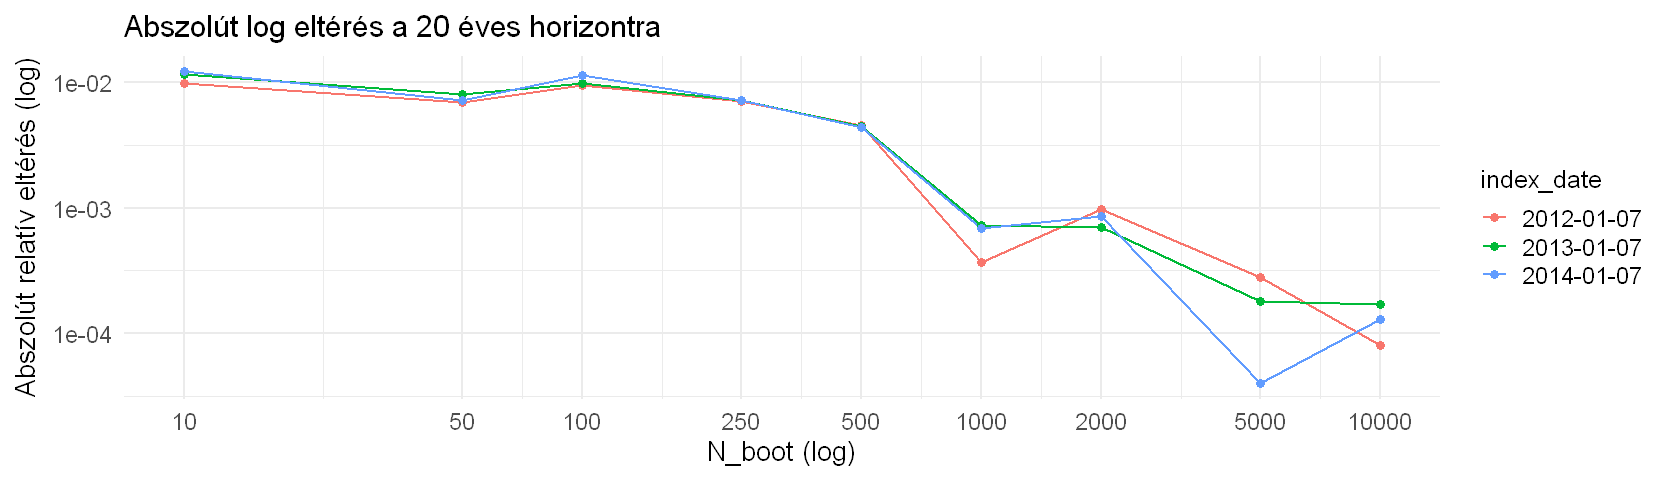

In [23]:
# Az N_boot szerinti konvergencia ábrázolása abszolút vagy előjeles relatív eltéréssel
plot_conv_delta <- function(use_abs = TRUE, x_log = TRUE, y_log = use_abs) {
  conv_plot <- data.table::copy(conv_compare)
  if (use_abs) conv_plot[, abs_rel_delta := abs(rel_delta)]

  # Az ábrázolt mennyiség és a feliratok beállítása
  y_col <- if (use_abs) "abs_rel_delta" else "rel_delta"
  x_lab <- if (x_log) "N_boot (log)" else "N_boot"
  y_lab_base <- if (use_abs) "Abszolút relatív eltérés" else "Relatív eltérés"
  y_lab <- if (y_log) paste0(y_lab_base, " (log)") else y_lab_base
  plot_title <- if (use_abs) {
    "Abszolút log eltérés a 20 éves horizontra"
  } else {
    "Előjeles eltérés a 20 éves horizontra"
  }

  # Az ábra alapbeállításai
  options(repr.plot.width = 14, repr.plot.height = 4)

  p <- ggplot2::ggplot(
    conv_plot,
    ggplot2::aes(x = N_boot, y = .data[[y_col]], color = index_date, group = index_date)
  ) +
    ggplot2::geom_line(linewidth = 0.8) +
    ggplot2::geom_point(size = 2.2) +
    ggplot2::labs(
      x = x_lab,
      y = y_lab,
      color = "index_date",
      title = plot_title
    ) +
    ggplot2::theme_minimal(base_size = 16) +
    ggplot2::theme(
      plot.title = ggplot2::element_text(size = 18),
      axis.title = ggplot2::element_text(size = 16),
      axis.text = ggplot2::element_text(size = 14),
      legend.title = ggplot2::element_text(size = 15),
      legend.text = ggplot2::element_text(size = 14)
    )

  # Az x tengely skálázása
  if (x_log) {
    p <- p + ggplot2::scale_x_log10(breaks = conv_n_boot)
  } else {
    p <- p + ggplot2::scale_x_continuous(breaks = conv_n_boot)
  }

  # Az y tengely skálázása vagy a nullavonal hozzáadása
  if (y_log) {
    p <- p + ggplot2::scale_y_log10()
  } else {
    p <- p + ggplot2::geom_hline(yintercept = 0, linewidth = 0.5, color = "grey60")
  }

  p
}

# Az abszolút relatív eltérés konvergenciaábrája logaritmikus tengelyeken
plot_conv_delta(use_abs = TRUE, x_log = TRUE, y_log = TRUE)


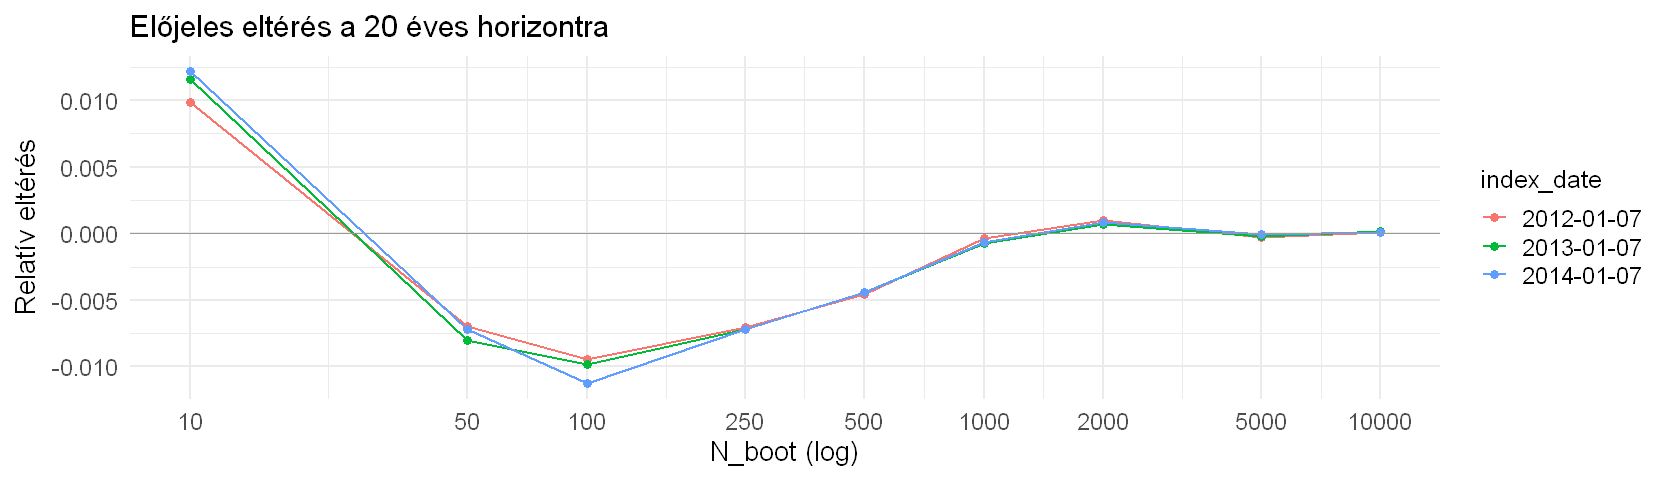

In [24]:
plot_conv_delta(use_abs = FALSE, x_log = TRUE, y_log = FALSE)

### 11. Megállapítás

A 6–10. szakasz eredményei összességében azt mutatják, hogy a több indexdátumra kiterjesztett implementáció numerikusan konzisztens a referencia-eljárással. 
- A 9. szakasz egyezési összesítő táblái (`summary_delta_P`, `summary_delta_q`) alapján a pontbecslések maximális abszolút relatív eltérése mind a teljes rácson, mind a `sim_inc_years = 10` részrácson `0.00083`, tehát az előre rögzített `10^-3` küszöb alatt marad. 
- A konfidencia-intervallumok határainál a legnagyobb eltérések a teljes rácson `0.00348` (`alpha = 0.025`) és `0.00178` (`alpha = 0.975`), a `sim_inc_years = 10` részrácson pedig `0.00147`, illetve `0.00116`; ezek mindegyike kisebb az intervallumhatárokra rögzített `5·10^-3` küszöbnél. Ennek megfelelően a bevezetőben rögzített egyezési feltételek a pontbecslésekre és a kvantilisalapú intervallumhatárokra egyaránt teljesülnek.

- A 6. és 7. szakasz rácsponti összevetései (`compare_all`, `compare_ci_all`), valamint a 8. szakasz seed-összesítő táblája (`summary_abs_delta`) nem jeleznek szisztematikus, egyirányú eltolódást a kiterjesztett eljárás javára vagy kárára. A pontbecslések előjeles relatív eltérésének átlaga minden szimulált konfigurációban kicsi, jellemzően `10^-4` nagyságrendű, miközben a `p_positive` értékei `0.2` és `0.5` között maradnak. Ez azt jelzi, hogy az eltérés előjele seedenként váltakozik, tehát a különbségek elsődlegesen Monte Carlo jellegűek, és nem egy stabil módszertani torzításból fakadnak.

- A táblákból egy további lényeges szerkezeti megfigyelés is kiolvasható. A tisztán counted esetekben, vagyis amikor `sim_inc_years = 0`, a referencia és a kiterjesztett implementáció a vizsgált rácspontokon teljes egyezést ad (lásd a 6. szakasz rácsponti összevetését és a 8. szakasz összefoglaló tábláját). A nem zérus eltérések ott jelennek meg, ahol a becsléshez a regiszter kezdete előtti szimulált incidens hozzájárulás is szükséges. A notebook eredményei azt mutatják, hogy a szimulált komponens megjelenésével az eltérések mérsékelten nőhetnek, miközben végig a rögzített tűréshatárokon belül maradnak.

- Végül a 10. szakasz konvergenciaábrái mind az abszolút, mind az előjeles eltérések esetén azt mutatják, hogy az `N_boot` növelésével a referencia- és a kiterjesztett kimenet különbsége csökken, vagyis a bevezetőben megfogalmazott konvergenciaelvárás empirikusan is teljesül. A notebook eredményei így együtt azt támasztják alá, hogy a többindexű kiterjesztés megőrzi a referencia-eljárással való numerikus összhangot.
